In [5]:
import numpy
import matplotlib
import nltk

nltk.download('brown') # corpus
nltk.download('universal_tagset') # simplified tag set

# loading the corpus
tagged_sentences = nltk.corpus.brown.tagged_sents(tagset='universal')

print(f"Total sentences: {len(tagged_sentences)}")
print(f"Example sentence: {tagged_sentences[0]}")

[nltk_data] Downloading package brown to
[nltk_data]     /Users/josephinebhadran/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package universal_tagset to
[nltk_data]     /Users/josephinebhadran/nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!


Total sentences: 57340
Example sentence: [('The', 'DET'), ('Fulton', 'NOUN'), ('County', 'NOUN'), ('Grand', 'ADJ'), ('Jury', 'NOUN'), ('said', 'VERB'), ('Friday', 'NOUN'), ('an', 'DET'), ('investigation', 'NOUN'), ('of', 'ADP'), ("Atlanta's", 'NOUN'), ('recent', 'ADJ'), ('primary', 'NOUN'), ('election', 'NOUN'), ('produced', 'VERB'), ('``', '.'), ('no', 'DET'), ('evidence', 'NOUN'), ("''", '.'), ('that', 'ADP'), ('any', 'DET'), ('irregularities', 'NOUN'), ('took', 'VERB'), ('place', 'NOUN'), ('.', '.')]


In [7]:
import random

random.seed(1234)
shuffled = list(tagged_sentences)
random.shuffle(shuffled)

# train test split
split = int(0.8 * len(shuffled))
train_sents = shuffled[:split]
test_sents = shuffled[split:]


print(f"training: {len(train_sents)} sentences")
print(f"testing: {len(test_sents)} sentences")

training: 45872 sentences
testing: 11468 sentences


In [13]:
# training
from collections import defaultdict


def train_hmm(sentences):
    transition_counts = defaultdict(lambda: defaultdict(int)) # dict for how many times tag B followed tag A
    emission_counts = defaultdict(lambda: defaultdict(int)) # dict for how many times this word appeared with this tag
    tag_counts = defaultdict(int) # total times this tag appeared


    for sentence in sentences:
        prev_tag = "<START>"

        for word, tag in sentence:
            word = word.lower()

            tag_counts[tag] += 1
            emission_counts[tag][word] += 1
            transition_counts[prev_tag][tag] += 1

            prev_tag = tag

        transition_counts[prev_tag]["<END>"] += 1

    
    # sanity check
    print(f"Tags found: {list(tag_counts.keys())}")
    print(f"Example emissions for NOUN: {list(emission_counts['NOUN'].items())[:5]}")

    return transition_counts, emission_counts, tag_counts


def compute_probabilities(transition_counts, emission_counts, tag_counts):
    transition_probs = defaultdict(lambda: defaultdict(float))
    emission_probs = defaultdict(lambda: defaultdict(float))

    # transition probabilities
    for prev_tag in transition_counts:
        total = sum(transition_counts[prev_tag].values())
        for tag in transition_counts[prev_tag]:
            transition_probs[prev_tag][tag] = transition_counts[prev_tag][tag] / total

    # emission probabilities
    for tag in emission_counts:
        total = tag_counts[tag]
        for word in emission_counts[tag]:
            emission_probs[tag][word] = emission_counts[tag][word] / total

    return transition_probs, emission_probs


In [15]:
transition_counts, emission_counts, tag_counts = train_hmm(train_sents)
transition_probs, emission_probs = compute_probabilities(transition_counts, emission_counts, tag_counts)

# sanity check
print(f"Transition probs from START: {dict(transition_probs['<START>'])}")
print(f"P(runs | VERB): {emission_probs['VERB']['runs']}")

Tags found: ['VERB', 'NOUN', 'ADP', 'DET', 'ADV', 'ADJ', '.', 'PRON', 'CONJ', 'PRT', 'NUM', 'X']
Example emissions for NOUN: [('nothing', 327), ('country', 254), ("tourists'", 1), ('comfort', 33), ('shoulders', 43)]
Transition probs from START: {'VERB': 0.04534356470177886, 'PRON': 0.15857167771189395, '.': 0.08931374258807115, 'NOUN': 0.14167683990233693, 'ADP': 0.12360481339379142, 'DET': 0.21267875828392047, 'PRT': 0.036645448203697244, 'NUM': 0.016502441576560865, 'CONJ': 0.048831531217300314, 'ADJ': 0.034247471224276245, 'ADV': 0.09210411580048831, 'X': 0.00047959539588419953}
P(runs | VERB): 6.84439273125492e-05


In [17]:
def viterbi(sentence, transition_probs, emission_probs, tag_counts):
    tags = list(tag_counts.keys())
    n = len(sentence)

    viterbi_probs = defaultdict(float)
    backpointer = [defaultdict(str) for _ in range(n)]

    # initialization (first word)
    first_word = sentence[0].lower()
    for tag in tags:
        trans = transition_probs["<START>"][tag]
        emiss = emission_probs[tag].get(first_word, 1e-10)
        viterbi_probs[tag] = trans * emiss
        backpointer[0][tag] = "<START>"

    # recursion on remaining words
    for i in range(1, n):
        word = sentence[i].lower()
        new_viterbi = defaultdict(float)

        for tag in tags:
            emiss = emission_probs[tag].get(word, 1e-10)

            best_prob = -1
            for prev_tag in tags:
                prob = viterbi_probs[prev_tag] * transition_probs[prev_tag][tag] * emiss
                if prob > best_prob:
                    best_prob = prob
                    best_prev = prev_tag

            new_viterbi[tag] = best_prob
            backpointer[i][tag] = best_prev

        viterbi_probs = new_viterbi

    # backtrack, find best final tag
    best_last_tag = None
    best_prob = -1
    for tag in tags:
        if viterbi_probs[tag] > best_prob:
            best_prob = viterbi_probs[tag]
            best_last_tag = tag

    result = [best_last_tag]
    for i in range(n-1, 0, -1):
        best_last_tag = backpointer[i][best_last_tag]
        result.append(best_last_tag)

    result.reverse()
    return result

# checking
test_sentence = ["the", "dog", "runs", "fast"]
predicted_tags = viterbi(test_sentence, transition_probs, emission_probs, tag_counts)
print(list(zip(test_sentence, predicted_tags)))

[('the', 'DET'), ('dog', 'NOUN'), ('runs', 'VERB'), ('fast', 'ADV')]


In [19]:
# evaluation function
def evaluate(test_sents, transition_probs, emission_probs, tag_counts):
    correct = 0
    total = 0

    for i, sentence in enumerate(test_sents):
        words = [word for word, tag in sentence]
        gold_tags = [tag for word, tag in sentence]
        predicted_tags = viterbi(words, transition_probs, emission_probs, tag_counts)

        for gold, pred in zip(gold_tags, predicted_tags):
            if gold == pred:
                correct += 1
            total += 1
    
        if i % 500 == 0:
            print(f"sentence {i} / {len(test_sents)}, running accuracy: {correct/total:.4f}")
    return correct / total

accuracy = evaluate(test_sents, transition_probs, emission_probs, tag_counts)
print(f"accuracy: {accuracy:.4f}")

sentence 0 / 11468, running accuracy: 0.9615
sentence 500 / 11468, running accuracy: 0.9624
sentence 1000 / 11468, running accuracy: 0.9609
sentence 1500 / 11468, running accuracy: 0.9617
sentence 2000 / 11468, running accuracy: 0.9620
sentence 2500 / 11468, running accuracy: 0.9621
sentence 3000 / 11468, running accuracy: 0.9619
sentence 3500 / 11468, running accuracy: 0.9616
sentence 4000 / 11468, running accuracy: 0.9610
sentence 4500 / 11468, running accuracy: 0.9608
sentence 5000 / 11468, running accuracy: 0.9610
sentence 5500 / 11468, running accuracy: 0.9609
sentence 6000 / 11468, running accuracy: 0.9608
sentence 6500 / 11468, running accuracy: 0.9603
sentence 7000 / 11468, running accuracy: 0.9602
sentence 7500 / 11468, running accuracy: 0.9599
sentence 8000 / 11468, running accuracy: 0.9601
sentence 8500 / 11468, running accuracy: 0.9601
sentence 9000 / 11468, running accuracy: 0.9600
sentence 9500 / 11468, running accuracy: 0.9599
sentence 10000 / 11468, running accuracy: 0.

Tags found: ['VERB', 'NOUN', 'ADP', 'DET', 'ADV', 'ADJ', '.', 'PRON', 'CONJ', 'PRT', 'NUM', 'X']
Example emissions for NOUN: [('nothing', 40), ('country', 21), ("tourists'", 1), ('comfort', 3), ('shoulders', 6)]
sentence 0 / 11468, running accuracy: 0.8846
sentence 500 / 11468, running accuracy: 0.9278
sentence 1000 / 11468, running accuracy: 0.9266
sentence 1500 / 11468, running accuracy: 0.9272
sentence 2000 / 11468, running accuracy: 0.9285
sentence 2500 / 11468, running accuracy: 0.9287
sentence 3000 / 11468, running accuracy: 0.9291
sentence 3500 / 11468, running accuracy: 0.9284
sentence 4000 / 11468, running accuracy: 0.9276
sentence 4500 / 11468, running accuracy: 0.9273
sentence 5000 / 11468, running accuracy: 0.9274
sentence 5500 / 11468, running accuracy: 0.9272
sentence 6000 / 11468, running accuracy: 0.9271
sentence 6500 / 11468, running accuracy: 0.9268
sentence 7000 / 11468, running accuracy: 0.9267
sentence 7500 / 11468, running accuracy: 0.9262
sentence 8000 / 11468, r

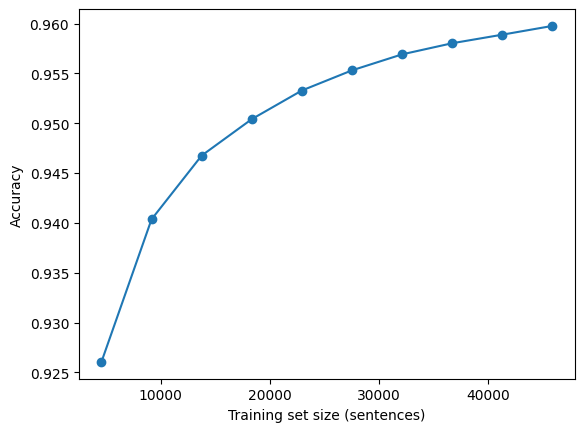

In [21]:
# learning curve experiment
import matplotlib.pyplot as plt

fractions = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
accuracies = []

for frac in fractions:
    size = int(frac * len(train_sents))
    subset = train_sents[:size]

    # retrain
    tc, ec, tagc = train_hmm(subset)
    tp, ep = compute_probabilities(tc, ec, tagc)

    # evaluate
    acc = evaluate(test_sents, tp, ep, tagc)
    accuracies.append(acc)
    print(f"training size: {size} sentences {{int(frac*100)}}%, accuracy: {acc:.4f}")

plt.plot([int(f * len(train_sents)) for f in fractions], accuracies, marker='o')
plt.xlabel("Training set size (sentences)")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
# def per_tag_accuracy(test_sents, transition_probs, emission_probs, tag_counts):
#     correct_per_tag = defaultdict(int)
#     total_per_tag = defaultdict(int)

#     for sentence in test_sents:
        